In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm
from ase.db import connect

from asmcmc.measurements import TrajectoryAnalyzer, RadialDistributionFunction, OrientationalCorrelationFunction, NematicOrderParameter, HeatCapacity, AverageEnthalpy, EffectiveSampleSize

plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})

In [2]:
temps = [40, 70, 85, 100, 115, 130, 145, 160, 175]
pressures = [1e-5, 1e-4, 3e-4]
press_names = ["1e-05", "0.0001", "0.0003"]

In [3]:
# Collect results for only 1e-5 pressure

seeds = {
    40: 12345,
    70: 12346,
    85: 12347,
    100: 12348,
    115: 12349,
    130: 12350,
    145: 12351,
    160: 12352,
    175: 12353
}

db_paths = [f"../results/npt_scan/T{temp}_P1e-05/{seeds[temp]}/simulation.db" for temp in temps]
trajs = {}
for temp, path in zip(temps, db_paths):
    frames = []
    with connect(path) as db:
        for row in db.select():
            frames.append(row.toatoms())
    trajs[temp] = frames

# Maximum radius valid for the RDF / orientational correlation.
#
# The minimum-image convention only resolves separations out to half the
# SHORTEST box edge. These NPT boxes are non-cubic (the columnar start leaves
# the column axis ~33-38 A vs ~26-31 A for the other two), so we must use the
# shortest edge -- frame.cell.lengths().min() -- not a single lattice vector.
# Take the global minimum over all frames AND all temperatures so every curve
# shares the same valid range (the box shrinks as T drops, so the cold end sets
# the limit).
min_lens = []
for temp in temps:
    cell_lens = [frame.cell.lengths().min() for frame in trajs[temp]]
    min_lens.append(np.min(cell_lens))

r_max = np.min(min_lens) / 2
print(f"r_max: {r_max}")

r_max: 13.212124269926463


In [4]:
# Bin widths chosen per observable, derived from r_max so the physical
# resolution is fixed regardless of the cutoff.
#   RDF: ~0.05 A -- fine enough to resolve the split crystalline peaks.
#   OCF: ~0.1 A  -- it averages P2 over the pairs in each shell, so coarser
#        bins pool more pairs and stay smooth (fine bins leave the near-contact
#        shells with only a handful of pairs, which spike).
rdf_bins = int(round(r_max / 0.05))
ocf_bins = int(round(r_max / 0.1))

# These are NPT runs, so the pressure-dependent observables get the run pressure:
# HeatCapacity uses Var(U + P V) for C_p, and AverageEnthalpy reports H = U + P V.
# Must match the pressure the trajectories were sampled at (P1e-05 above).
pressure = 1e-5  # eV/A^3

measurements = {}

for temp, path in zip(temps, db_paths):
    analyzer = TrajectoryAnalyzer(path)

    analyzer.add_measurement("rdf", RadialDistributionFunction(r_max=r_max, num_bins=rdf_bins))
    analyzer.add_measurement("ocf", OrientationalCorrelationFunction(r_max=r_max, num_bins=ocf_bins))
    analyzer.add_measurement("nop", NematicOrderParameter())
    analyzer.add_measurement("c_p", HeatCapacity(temp, 125, pressure=pressure))
    analyzer.add_measurement("enthalpy", AverageEnthalpy(pressure=pressure))

    measurements[temp] = analyzer.run_analysis()

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

In [5]:
# --- Plotting helpers (matplotlib-native) --------------------------------------
# Four views of a per-temperature curve f(r) -- RDF g(r) or OCF s2(r) -- that
# replace the seaborn ridgeline. All share one cold->hot temperature colormap.

T_CMAP = plt.cm.coolwarm
T_NORM = Normalize(min(temps), max(temps))


def _curve(measurements, meas_key, val_key, temp):
    m = measurements[temp][meas_key]
    return np.asarray(m["r"], float), np.asarray(m[val_key], float)


def _edges_from_centers(c):
    """Uniform bin edges from evenly spaced bin centers."""
    c = np.asarray(c, float)
    dc = c[1] - c[0]
    return np.concatenate([c - dc / 2.0, [c[-1] + dc / 2.0]])


def _temp_edges(ts):
    """Cell edges for a (possibly non-uniform) temperature axis."""
    ts = np.asarray(ts, float)
    mids = (ts[:-1] + ts[1:]) / 2.0
    return np.concatenate([[2 * ts[0] - mids[0]], mids, [2 * ts[-1] - mids[-1]]])


def _save(fig, savepath):
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
        print(f"saved {savepath}")


def plot_heatmap(measurements, meas_key, val_key, xlabel, cbar_label, title,
                 diverging=False, savepath=None):
    """r (x) by T (y) field, color = f(r). Robust to per-bin noise."""
    r, _ = _curve(measurements, meas_key, val_key, temps[0])
    Z = np.vstack([_curve(measurements, meas_key, val_key, t)[1] for t in temps])

    fig, ax = plt.subplots(figsize=(8, 4.5))
    if diverging:
        lim = np.nanmax(np.abs(Z))
        norm = TwoSlopeNorm(vcenter=0.0, vmin=-lim, vmax=lim)
        # below-contact bins hold no pairs and finalize() leaves them at exactly
        # 0, which a diverging map paints white at its center. Mask those empties
        # and color them black so they match the sequential (magma) RDF heatmap.
        cmap = plt.get_cmap("RdBu_r").copy()
        cmap.set_bad("black")
        Z = np.ma.masked_where(Z == 0.0, Z)
    else:
        # clip the tall crystalline first peak so the rest stays legible
        norm = Normalize(vmin=0.0, vmax=np.percentile(Z, 99))
        cmap = "magma"
    pcm = ax.pcolormesh(_edges_from_centers(r), _temp_edges(temps), Z,
                        cmap=cmap, norm=norm, shading="flat")
    fig.colorbar(pcm, ax=ax, label=cbar_label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("T (K)")
    ax.set_title(title)
    fig.tight_layout()
    _save(fig, savepath)
    return fig


def plot_overlaid(measurements, meas_key, val_key, xlabel, ylabel, title,
                  ref_line=None, savepath=None):
    """All temperature curves on one axes, colored by T with a colorbar."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for t in temps:
        r, v = _curve(measurements, meas_key, val_key, t)
        ax.plot(r, v, color=T_CMAP(T_NORM(t)), lw=1.2)
    if ref_line is not None:
        ax.axhline(ref_line, ls="--", lw=0.8, color="0.4")
    sm = ScalarMappable(norm=T_NORM, cmap=T_CMAP)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="T (K)")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.tight_layout()
    _save(fig, savepath)
    return fig


def plot_small_multiples(measurements, meas_key, val_key, xlabel, ylabel, title,
                         ref_line=None, ncols=3, savepath=None):
    """One clean panel per temperature, shared axes."""
    n = len(temps)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 2.6 * nrows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, t in zip(axes, temps):
        r, v = _curve(measurements, meas_key, val_key, t)
        ax.plot(r, v, color=T_CMAP(T_NORM(t)), lw=1.2)
        if ref_line is not None:
            ax.axhline(ref_line, ls="--", lw=0.7, color="0.5")
        ax.text(0.96, 0.9, f"{t} K", transform=ax.transAxes,
                ha="right", va="top", fontweight="bold")
    for ax in axes[n:]:
        ax.axis("off")
    fig.supxlabel(xlabel)
    fig.supylabel(ylabel)
    fig.suptitle(title)
    fig.tight_layout()
    _save(fig, savepath)
    return fig


def plot_ridgeline(measurements, meas_key, val_key, xlabel, title,
                   overlap=0.45, ref_line=None, savepath=None):
    """Matplotlib-native joyplot: stacked curves, coldest at the bottom."""
    curves = {t: _curve(measurements, meas_key, val_key, t) for t in temps}
    vmin = min(v.min() for _, v in curves.values())
    vmax = max(v.max() for _, v in curves.values())
    step = (vmax - vmin) * (1.0 - overlap)

    fig, ax = plt.subplots(figsize=(8, 0.7 * len(temps) + 1.5))
    for i, t in enumerate(temps):  # coldest (i=0) at the bottom
        r, v = curves[t]
        base = i * step
        color = T_CMAP(T_NORM(t))
        y = base + (v - vmin)
        z = len(temps) - i
        ax.fill_between(r, base, y, color=color, alpha=0.85, lw=0, zorder=z)
        ax.plot(r, y, color="w", lw=0.8, zorder=z)
        if ref_line is not None:
            ax.hlines(base + (ref_line - vmin), r[0], r[-1],
                      lw=0.6, ls="--", color="0.4", zorder=z)
        ax.text(r[0], base, f"{t} K", va="bottom", ha="left",
                fontsize=8, fontweight="bold", color=color, zorder=z + 1)
    ax.set_yticks([])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    for s in ("left", "right", "top"):
        ax.spines[s].set_visible(False)
    fig.tight_layout()
    _save(fig, savepath)
    return fig

saved ../results/npt_scan/rdf_heatmap_P1e-05.png
saved ../results/npt_scan/rdf_overlaid_P1e-05.png
saved ../results/npt_scan/rdf_grid_P1e-05.png
saved ../results/npt_scan/rdf_ridgeline_P1e-05.png


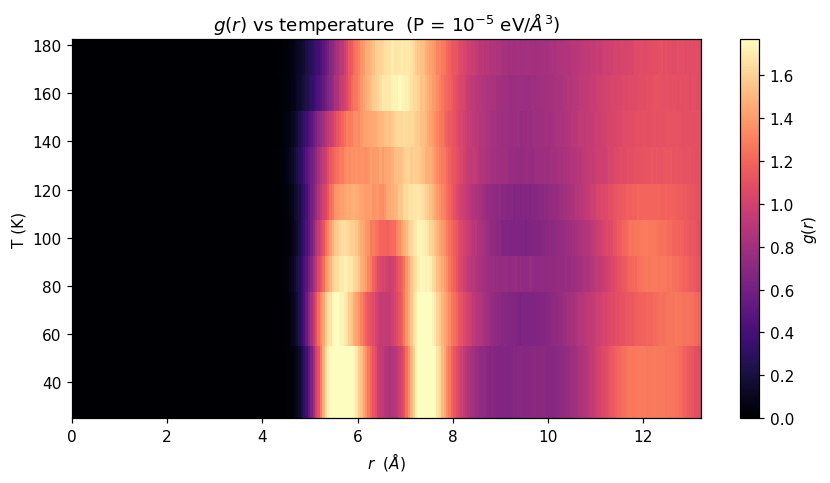

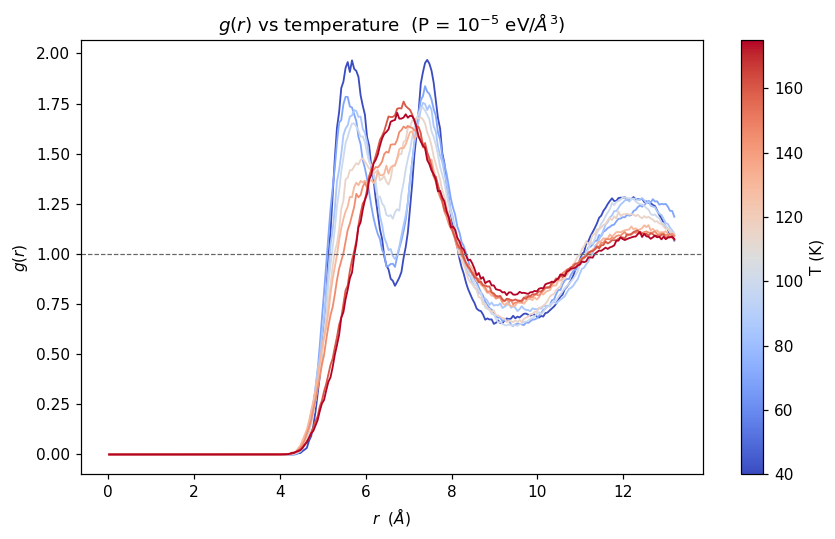

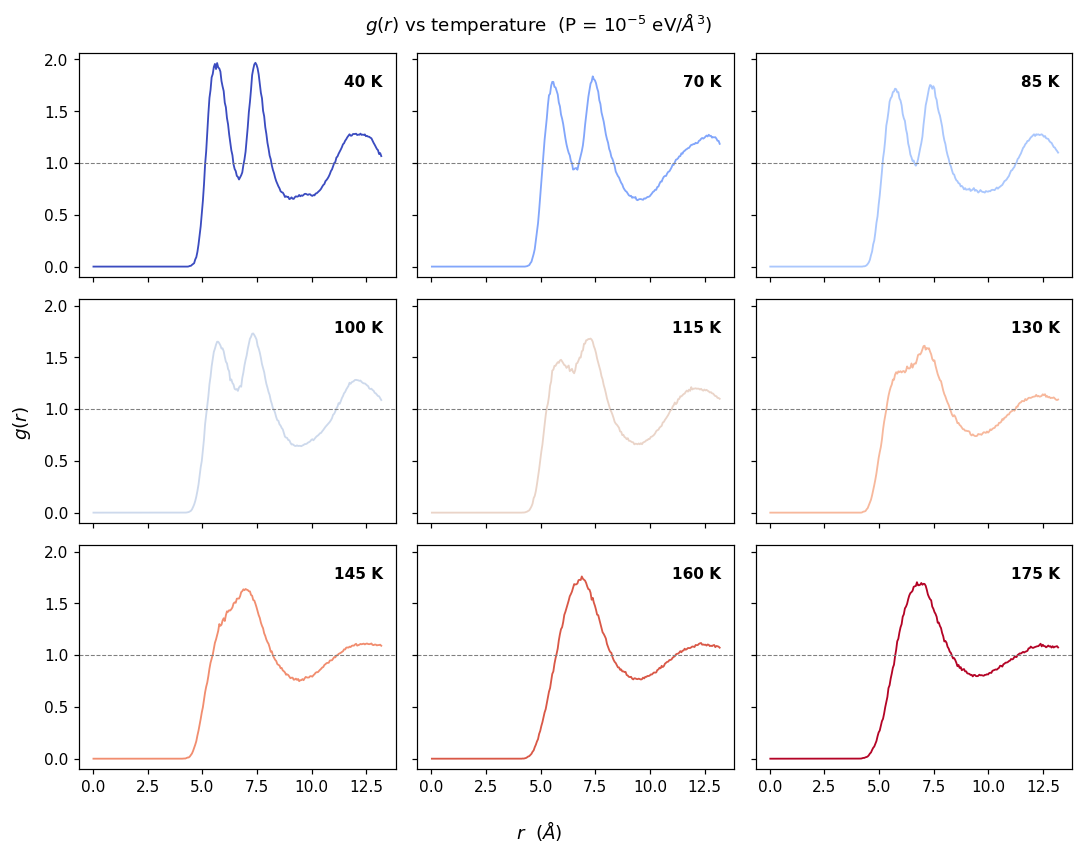

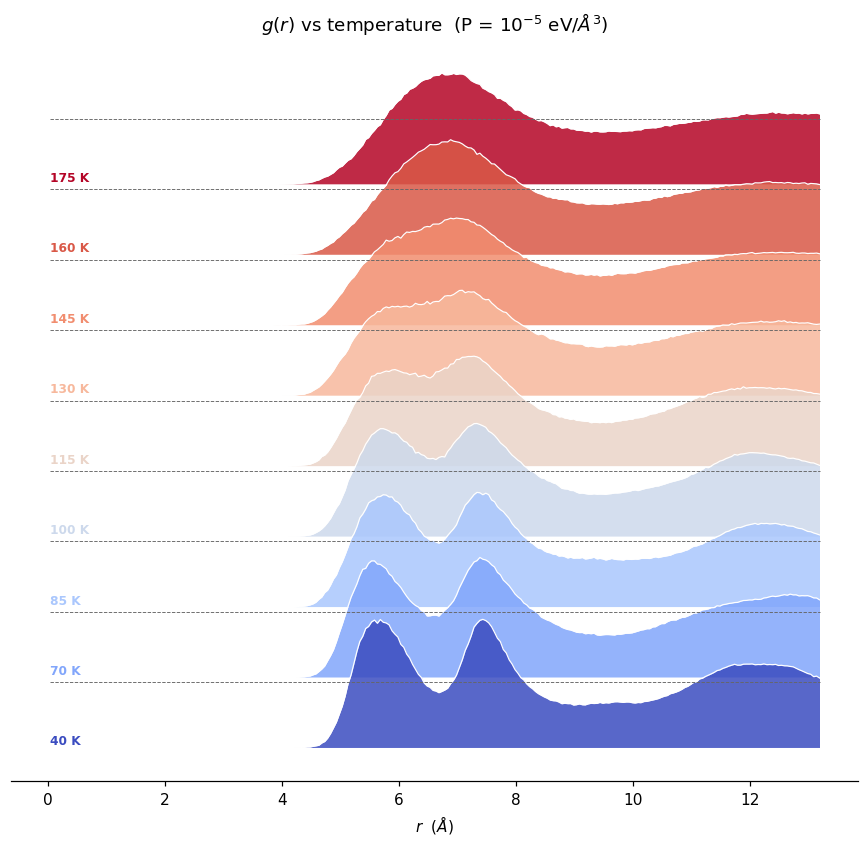

In [6]:
# Radial distribution function g(r) vs temperature (P = 1e-5 eV/A^3).
# Sharp split peaks at low T (crystal) broaden and merge into a liquid-like g(r)
# as temperature rises. Rendered four ways for comparison.
xlabel = r"$r$  ($\AA$)"
rdf_title = r"$g(r)$ vs temperature  (P = $10^{-5}$ eV/$\AA^3$)"
out = "../results/npt_scan"

plot_heatmap(measurements, "rdf", "g_r", xlabel, r"$g(r)$", rdf_title,
             savepath=f"{out}/rdf_heatmap_P1e-05.png")
plot_overlaid(measurements, "rdf", "g_r", xlabel, r"$g(r)$", rdf_title,
              ref_line=1.0, savepath=f"{out}/rdf_overlaid_P1e-05.png")
plot_small_multiples(measurements, "rdf", "g_r", xlabel, r"$g(r)$", rdf_title,
                     ref_line=1.0, savepath=f"{out}/rdf_grid_P1e-05.png")
plot_ridgeline(measurements, "rdf", "g_r", xlabel, rdf_title,
               ref_line=1.0, savepath=f"{out}/rdf_ridgeline_P1e-05.png")
plt.show()

saved ../results/npt_scan/ocf_heatmap_P1e-05.png
saved ../results/npt_scan/ocf_overlaid_P1e-05.png
saved ../results/npt_scan/ocf_grid_P1e-05.png
saved ../results/npt_scan/ocf_ridgeline_P1e-05.png


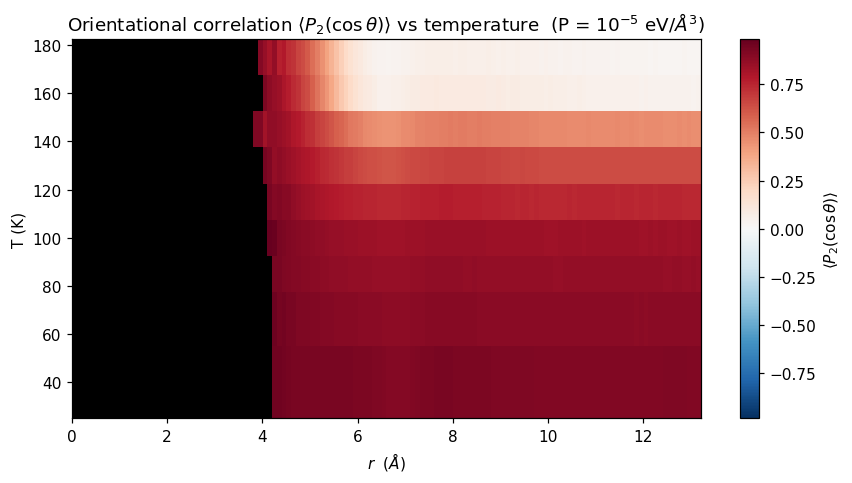

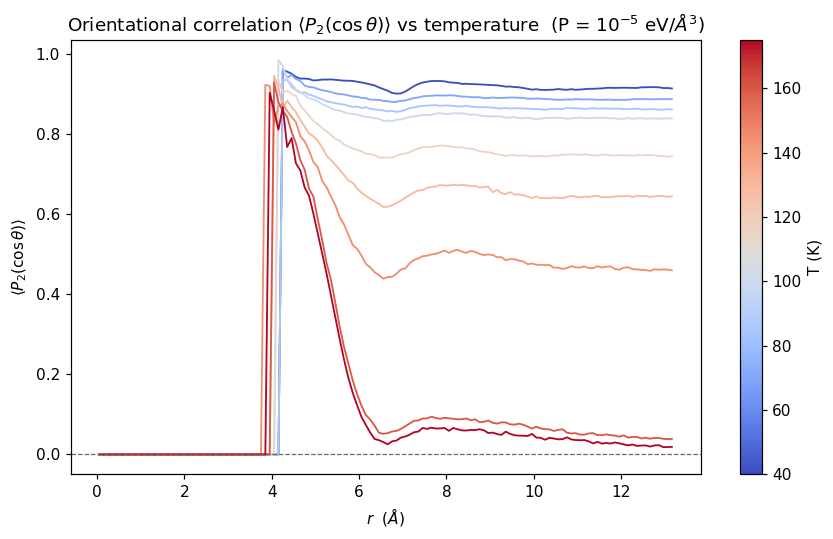

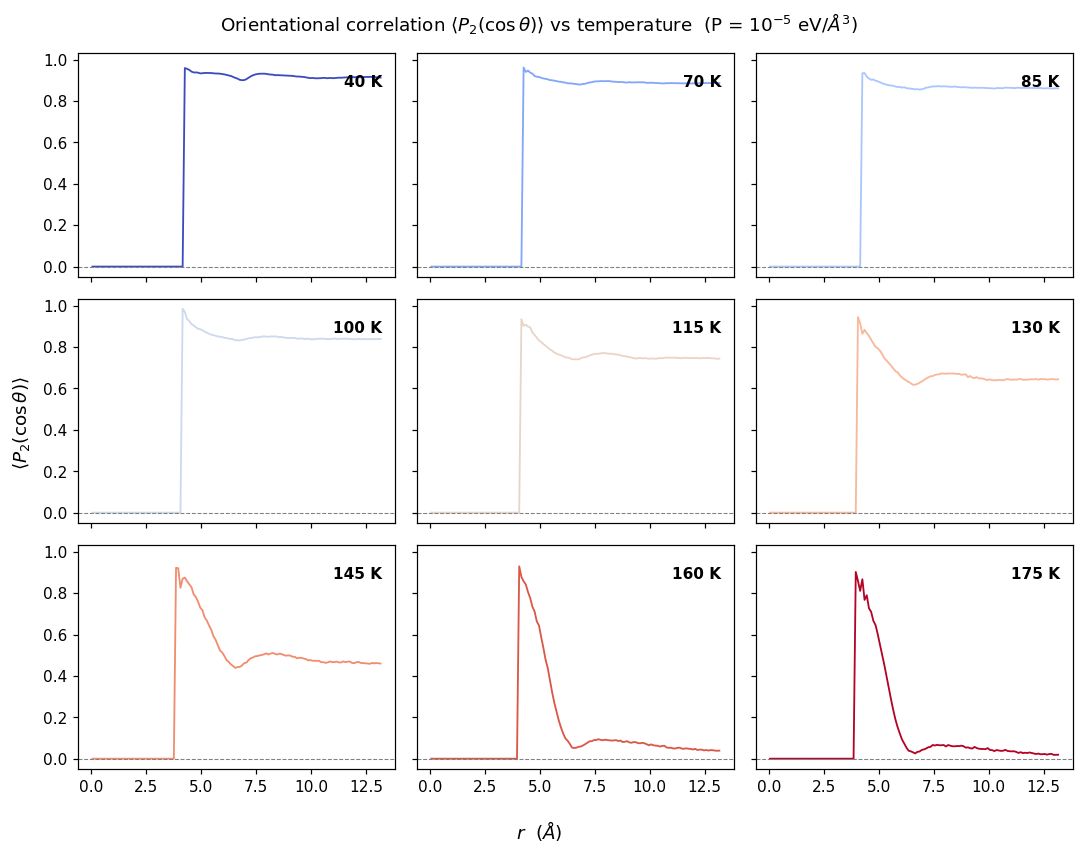

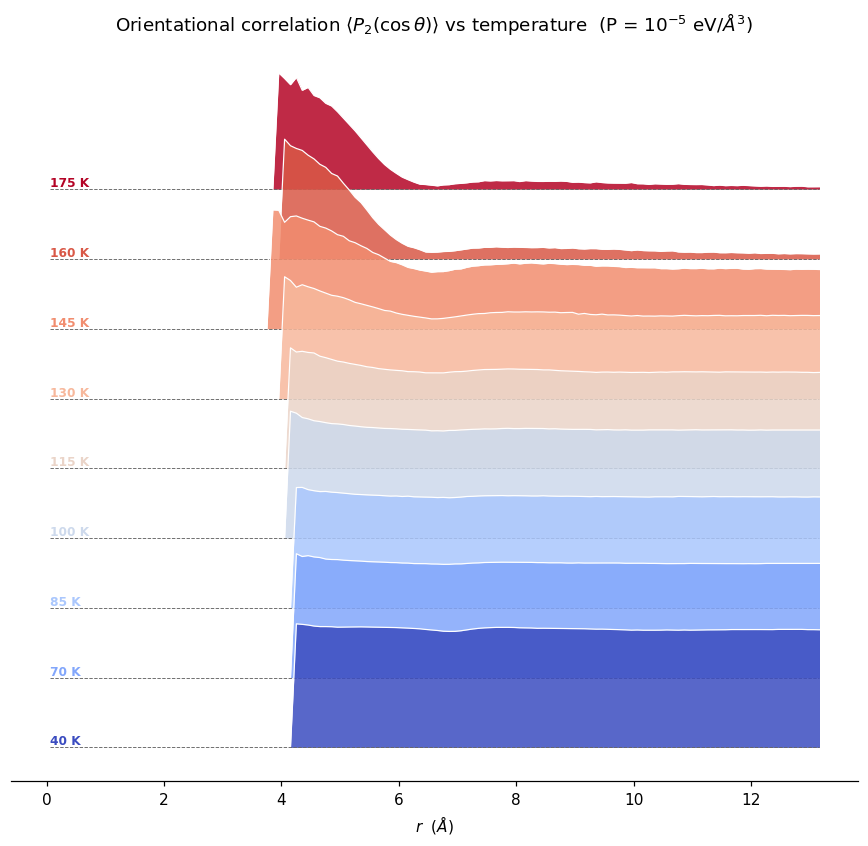

In [7]:
# Orientational correlation s2(r) = <P2(cos theta)> vs temperature.
# Long-range order (s2 high out to large r) at low T collapses toward 0 (random
# relative orientation) as the system disorders. The heatmap uses a diverging
# colormap centered at 0 since P2 can go negative. Rendered four ways.
xlabel = r"$r$  ($\AA$)"
ylabel = r"$\langle P_2(\cos\theta)\rangle$"
ocf_title = r"Orientational correlation $\langle P_2(\cos\theta)\rangle$ vs temperature  (P = $10^{-5}$ eV/$\AA^3$)"
out = "../results/npt_scan"

plot_heatmap(measurements, "ocf", "s2_r", xlabel, ylabel, ocf_title,
             diverging=True, savepath=f"{out}/ocf_heatmap_P1e-05.png")
plot_overlaid(measurements, "ocf", "s2_r", xlabel, ylabel, ocf_title,
              ref_line=0.0, savepath=f"{out}/ocf_overlaid_P1e-05.png")
plot_small_multiples(measurements, "ocf", "s2_r", xlabel, ylabel, ocf_title,
                     ref_line=0.0, savepath=f"{out}/ocf_grid_P1e-05.png")
plot_ridgeline(measurements, "ocf", "s2_r", xlabel, ocf_title,
               ref_line=0.0, savepath=f"{out}/ocf_ridgeline_P1e-05.png")
plt.show()

In [8]:
# --- Scalar-vs-temperature helper ----------------------------------------------
# For observables that reduce each trajectory to a single number (heat capacity,
# nematic order S): one point per state point, plotted against temperature.

def plot_vs_temp(values, ylabel, title, band=None, ref_line=None, savepath=None):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ts = np.asarray(temps, float)
    v = np.asarray(values, float)
    ax.plot(ts, v, marker="o", lw=1.5, color="0.2", zorder=3)
    if band is not None:
        b = np.asarray(band, float)
        ax.fill_between(ts, v - b, v + b, color="0.6", alpha=0.25, lw=0,
                        label="per-frame std")
        ax.legend(frameon=False)
    if ref_line is not None:
        ax.axhline(ref_line, ls="--", lw=0.8, color="0.5")
    ax.set_xlabel("T (K)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.tight_layout()
    _save(fig, savepath)
    return fig

saved ../results/npt_scan/cp_vs_T_P1e-05.png


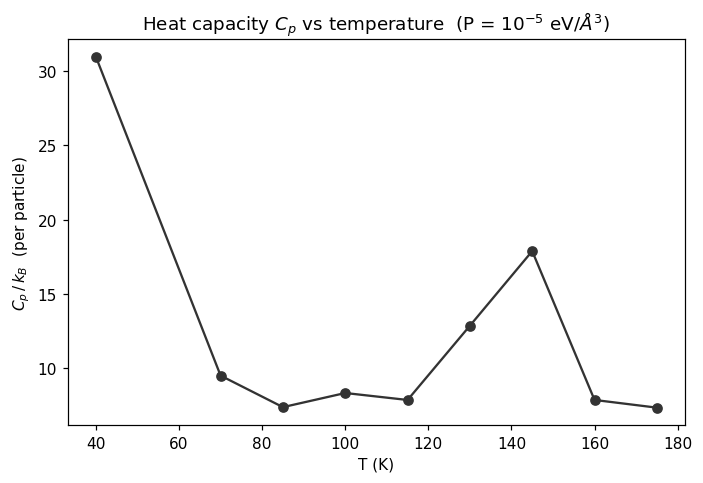

In [9]:
# Heat capacity C_p vs temperature (P = 1e-5 eV/A^3). HeatCapacity was given the
# run pressure, so it returns the per-particle C_p from the enthalpy fluctuation
# Var(U + P V); dividing by BOLTZCONST expresses it in units of k_B. A peak marks
# the order-disorder transition, where enthalpy fluctuations are largest.
from asmcmc.metropolis import BOLTZCONST

out = "../results/npt_scan"
cp_kB = [measurements[t]["c_p"] / BOLTZCONST for t in temps]
plot_vs_temp(
    cp_kB,
    ylabel=r"$C_p\,/\,k_B$  (per particle)",
    title=r"Heat capacity $C_p$ vs temperature  (P = $10^{-5}$ eV/$\AA^3$)",
    savepath=f"{out}/cp_vs_T_P1e-05.png",
)
plt.show()

saved ../results/npt_scan/nematic_S_vs_T_P1e-05.png


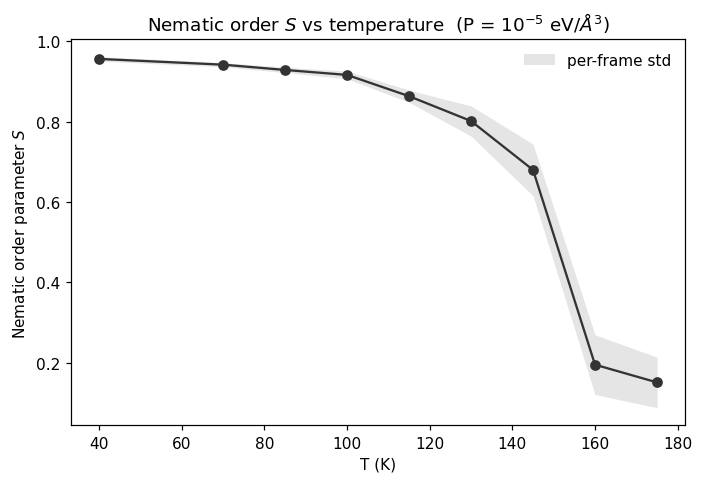

In [10]:
# Nematic order parameter S vs temperature (P = 1e-5 eV/A^3). S ~ 1 in the
# orientationally ordered phase at low T and falls toward 0 as the system
# becomes isotropic. The shaded band is the per-frame fluctuation in S (its std
# across frames -- a measure of orientational fluctuation, not a standard error
# of the mean), which itself tends to swell near the transition.
out = "../results/npt_scan"
S = [measurements[t]["nop"]["S"] for t in temps]
S_std = [measurements[t]["nop"]["S_std"] for t in temps]
plot_vs_temp(
    S,
    ylabel=r"Nematic order parameter $S$",
    title=r"Nematic order $S$ vs temperature  (P = $10^{-5}$ eV/$\AA^3$)",
    band=S_std,
    savepath=f"{out}/nematic_S_vs_T_P1e-05.png",
)
plt.show()

saved ../results/npt_scan/enthalpy_vs_T_P1e-05.png


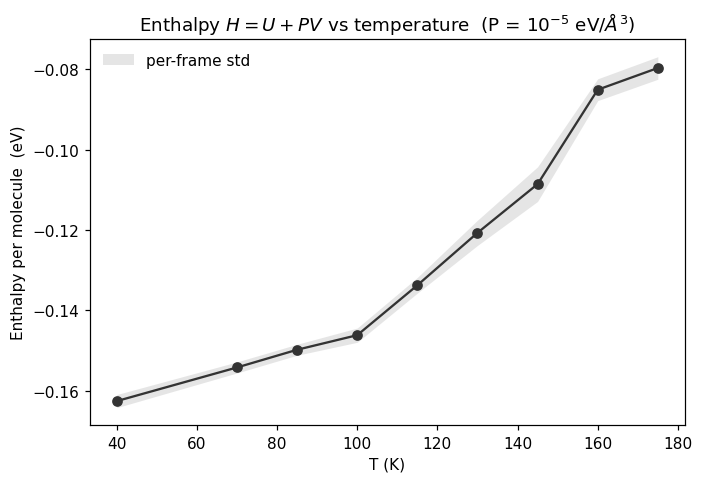

In [11]:
# Enthalpy per molecule H = U + P V vs temperature (P = 1e-5 eV/A^3). H rises
# smoothly with T, and its slope is C_p -- so the steepest stretch should line
# up with the C_p peak above (a useful cross-check). The shaded band is the
# per-frame std of H (orientational/volume fluctuation, not a standard error of
# the mean); Var(H) is itself proportional to C_p.
out = "../results/npt_scan"
N = len(trajs[temps[0]][0])  # molecules per frame
H = [measurements[t]["enthalpy"][0] / N for t in temps]
H_std = [measurements[t]["enthalpy"][1] / N for t in temps]
plot_vs_temp(
    H,
    ylabel=r"Enthalpy per molecule  (eV)",
    title=r"Enthalpy $H = U + PV$ vs temperature  (P = $10^{-5}$ eV/$\AA^3$)",
    band=H_std,
    savepath=f"{out}/enthalpy_vs_T_P1e-05.png",
)
plt.show()